<a href="https://colab.research.google.com/github/leesasang/codein_study/blob/main/%EC%BD%94%EB%93%9C%EC%9D%B8_%EA%B0%9C%EC%9D%B8%ED%94%84%EB%A1%9C%EC%A0%9D%ED%8A%B8_%EC%9D%B4%EC%B1%84%EC%97%B0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install opencv-python

In [3]:
import os

os.makedirs('/content/good', exist_ok=True)
os.makedirs('/content/bad/dark', exist_ok=True)
os.makedirs('/content/bad/blurry', exist_ok=True)

In [12]:
def extract_features(image_path):
    img = cv2.imread(image_path)

    if img is None:
        print("이미지 못 읽음:", image_path)
        return None, None

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    mean = np.mean(gray)
    var = np.var(gray)

    return mean, var


In [13]:
data = []

folders = ['good', 'bad/dark', 'bad/blurry']

for folder in folders:
    folder_path = f'/content/{folder}'

    for file in os.listdir(folder_path):

        if not file.lower().endswith(('.png', '.jpg', '.jpeg')):
            continue

        path = os.path.join(folder_path, file)

        mean, var = extract_features(path)

        if mean is None:
            continue

        label = folder.split('/')[-1]
        data.append([file, label, mean, var])

In [14]:
df = pd.DataFrame(data, columns=['file','label','mean','var'])

df

,file,label,mean,var
0,IMG_4344.JPG,good,129.260646,2894.646661
1,IMG_3368.JPG,good,139.093600,2582.840201
2,dclassic 2025-11-19 144158.494.jpg,good,168.120914,2836.986964
3,IMG_8397.JPG,good,143.270848,4845.137915
4,fqs 2025-11-10 213932.790.jpg,good,74.913033,2789.615060
5,fqs 2025-11-11 142741.280.jpg,good,133.760465,7039.036043
6,41fd0be686d31cfbdd03363cdd6a1094.jpg,good,100.411327,3904.603483
7,IMG_6490.JPG,good,140.348135,2169.985929
8,IMG_0353.JPG,good,136.907397,4609.925694
9,fqs 2025-11-10 212614.618.jpg,good,65.773567,5090.035207


In [18]:
df.groupby('label')[['mean','var']].mean()

,mean,var
label,,
blurry,109.943490,2841.395993
dark,39.539712,980.999412
good,123.185993,3876.281316


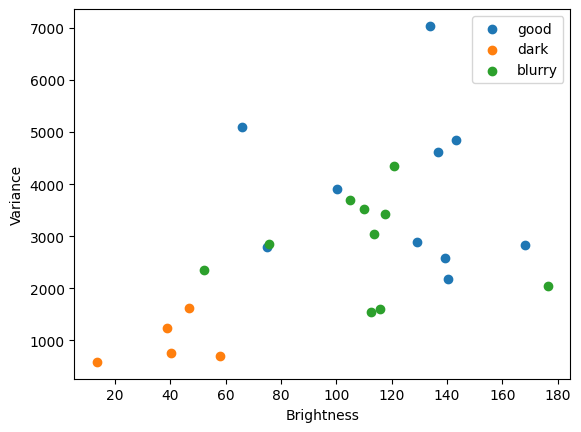

In [19]:
import matplotlib.pyplot as plt

for label in df['label'].unique():
    subset = df[df['label']==label]
    plt.scatter(subset['mean'], subset['var'], label=label)

plt.xlabel('Brightness')
plt.ylabel('Variance')
plt.legend()
plt.show()

In [20]:
def classify(mean, var):
    if mean < 60:
        return "dark"
    elif var < 3000:
        return "blurry"
    else:
        return "good"

In [21]:
df['pred'] = df.apply(lambda x: classify(x['mean'], x['var']), axis=1)

df

,file,label,mean,var,pred
0,IMG_4344.JPG,good,129.260646,2894.646661,blurry
1,IMG_3368.JPG,good,139.093600,2582.840201,blurry
2,dclassic 2025-11-19 144158.494.jpg,good,168.120914,2836.986964,blurry
3,IMG_8397.JPG,good,143.270848,4845.137915,good
4,fqs 2025-11-10 213932.790.jpg,good,74.913033,2789.615060,blurry
5,fqs 2025-11-11 142741.280.jpg,good,133.760465,7039.036043,good
6,41fd0be686d31cfbdd03363cdd6a1094.jpg,good,100.411327,3904.603483,good
7,IMG_6490.JPG,good,140.348135,2169.985929,blurry
8,IMG_0353.JPG,good,136.907397,4609.925694,good
9,fqs 2025-11-10 212614.618.jpg,good,65.773567,5090.035207,good


In [22]:
accuracy = (df['label'] == df['pred']).mean()
print("정확도:", accuracy)

정확도: 0.56


In [23]:
import gradio as gr
import cv2
import numpy as np

def classify_image(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    mean = np.mean(gray)
    var = np.var(gray)

    if mean < 80:
        result = "dark"
    elif var < 500:
        result = "blurry"
    else:
        result = "good"

    return f"밝기: {mean:.2f}, 분산: {var:.2f}, 결과: {result}"

demo = gr.Interface(fn=classify_image, inputs="image", outputs="text")
demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://e99b47b7ec415f9104.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
